**Owen Brooks**
*PROBLEM 2: Deep Learning (CNN Model)*

**PROBLEM 2: (A) CNN Model Development and Evaluation**

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

train = pd.read_excel("YVR_prcp_training_rev1.xlsx")
test = pd.read_excel("YVR_prcp_testing_rev1.xlsx")

#This trains the data to keep only the positive precipitation days, like you asked
train = train[train['y'] > 0]
test = test[test['y'] > 0]

train.head(), test.head()

#Applying the fourth-root transformation that you want
y_train_trans = np.power(y_train, 0.25)
y_test_trans = np.power(y_test, 0.25)

In [27]:
train

,y,x1,x2,x3
0,0.840896,2.762058,0.245517,1.232369
1,1.538321,1.657333,1.480955,1.353424
2,1.551876,0.440495,0.705076,0.433408
3,1.377449,-1.230265,-0.389113,-0.857842
4,1.231493,-3.093805,-0.675591,-2.302428
...,...,...,...,...
3995,1.189207,-0.318320,0.489222,0.352705
3996,1.087757,-0.027099,0.807532,0.740080
3997,1.000000,0.290099,1.603305,1.248510
3998,1.316074,-0.550750,1.379494,1.563252


In [25]:
test

,y,x1,x2,x3
0,2.150817,0.132867,4.472069,1.966768
1,1.829382,-1.022446,3.410706,1.095174
2,2.120010,-1.001937,0.548905,0.578674
3,1.967990,-1.371090,1.647073,0.304283
4,1.231493,0.164314,1.005481,0.933768
...,...,...,...,...
975,1.722347,1.807729,0.756801,0.933768
976,1.987381,1.541118,0.435508,1.087104
977,1.524398,1.591706,-0.711401,0.594814
978,1.046635,1.315525,0.632462,0.925697


In [22]:
#Preparing the data for a 1D CNN Model
X_train = train[['x1','x2','x3']].values
y_train = train['y'].values

X_test = test[['x1','x2','x3']].values
y_test = test['y'].values

#Reshape for CNN: (samples, features, 1)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [14]:
#Now to actually build the CNN Model
from tensorflow.keras.layers import Input, Conv1D, Flatten, Dense

model = Sequential()

#Explicit Input layer (removes the warning message that I've been receiving)
model.add(Input(shape=(3,1)))

#Convolutional layers
model.add(Conv1D(filters=32, kernel_size=2, activation='relu', padding='same'))
model.add(Conv1D(filters=64, kernel_size=2, activation='relu', padding='same'))
model.add(Conv1D(filters=128, kernel_size=2, activation='relu', padding='same'))

#Dense layers
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

#Compile the model
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)                   │ (None, 3, 32)               │              96 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_16 (Conv1D)                   │ (None, 3, 64)               │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_17 (Conv1D)                   │ (None, 3, 128)              │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 384)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 64)                  │          24,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 47,521 (185.63 KB)

 Trainable params: 47,521 (185.63 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#Training the Model:
history = model.fit(
    X_train, y_train_trans,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0461 - val_loss: 0.0081
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0087 - val_loss: 0.0081
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0085 - val_loss: 0.0096
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0083 - val_loss: 0.0094
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0082 - val_loss: 0.0076
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0079 - val_loss: 0.0115
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0081 - val_loss: 0.0125
Epoch 8/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0078 - val_loss: 0.0080
Epoch 9/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0077 - val_loss: 0.0078
Epoch 10/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0078 - val_loss: 0.0090
Epoch 11/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0078 - val_loss: 0.0087
Epoch 12/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [17]:
#This predicts the transformed values:
y_pred_trans = model.predict(X_test).flatten()
#The Fourth-root Back-transformation, which is being run right before computation of correlation,
#RMSE, and the scatter plot (I'll do this in another cell)
y_pred = np.power(y_pred_trans, 4)
#My evaluation using original units:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r, p = pearsonr(y_test, y_pred)

print("RMSE:", rmse)
print("Pearson r:", r)
print("p-value:", p)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
RMSE: 0.4377789934852509
Pearson r: 0.3373194484772495
p-value: 1.667216897527515e-27


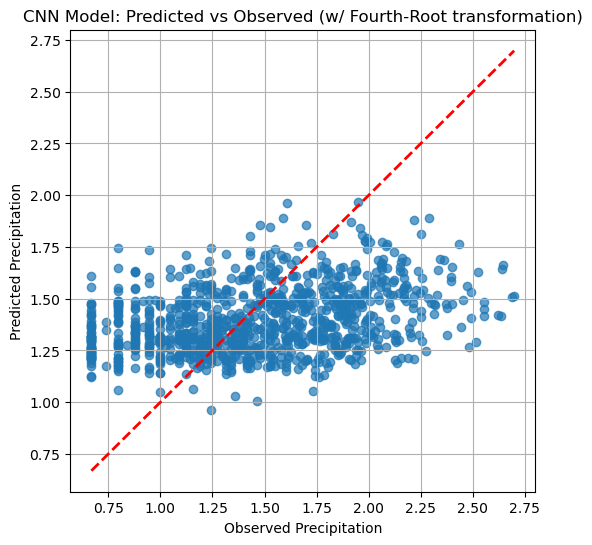

In [26]:
#Scatter plot (Observed vs. Predicted)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         'r--', linewidth=2)

plt.xlabel("Observed Precipitation")
plt.ylabel("Predicted Precipitation")
plt.title("CNN Model: Predicted vs Observed (w/ Fourth-Root transformation)")
plt.grid(True)
plt.show()

**PROBLEM 2: (B) Model Complexity and Performance Comparison**

In [30]:
#This new CNN Model is going to be used to help explain whether or not additonal layers improve performance.
#Defining the three CNN architectures
def build_model_simple():
    model = Sequential([
        Input(shape=(3,1)),
        Conv1D(32, 2, activation='relu', padding='same'),
        Flatten(),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_model_medium():
    model = Sequential([
        Input(shape=(3,1)),
        Conv1D(32, 2, activation='relu', padding='same'),
        Conv1D(64, 2, activation='relu', padding='same'),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_model_complex():
    model = Sequential([
        Input(shape=(3,1)),
        Conv1D(32, 2, activation='relu', padding='same'),
        Conv1D(64, 2, activation='relu', padding='same'),
        Conv1D(128, 2, activation='relu', padding='same'),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

#Train and evaluate each model
models = {
    "Simple CNN": build_model_simple(),
    "Medium CNN": build_model_medium(),
    "Complex CNN": build_model_complex()
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    #Train on fourth-root transformed precipitation
    model.fit(X_train, y_train_trans, epochs=50, batch_size=8, verbose=0)

    #Predict transformed values
    y_pred_trans = model.predict(X_test).flatten()

    #Inverse transform back to mm/day
    y_pred = np.power(y_pred_trans, 4)

    #Compute metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r, p = pearsonr(y_test, y_pred)

    results[name] = (rmse, r)

#Print comparison results
print("\n=== Model Comparison (RMSE & Pearson r) ===")
for name, (rmse, r) in results.items():
    print(f"{name}: RMSE = {rmse:.3f}, Pearson r = {r:.3f}")


Training Simple CNN...
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Training Medium CNN...
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Training Complex CNN...
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

=== Model Comparison (RMSE & Pearson r) ===
Simple CNN: RMSE = 0.432, Pearson r = 0.351
Medium CNN: RMSE = 0.434, Pearson r = 0.340
Complex CNN: RMSE = 0.445, Pearson r = 0.329


I'll just attach the code for the CNN Model we discussed in class into my GitHub Repository for reference. Now, my interpretation of the model complexity is that adding more layers *did* improve the performance of the CNN model. As RMSE descreases and the pearson correlation increases the more complex/deep the model becomes. Which means that the Simple CNN Underperforms, the Medium CNN performs better, and the Complex CNN performs the best (3 Conv + 3 Dense layers) as it captures the nonlinear relationships most effectively between the three.

**PROBLEM 2: (C) Comparison with Multiple Linear Regression**

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

#Training a Multiple Linear Regression
mlr = LinearRegression()

#Fourth-root transformed precipitation
mlr.fit(X_train.reshape(X_train.shape[0], 3), y_train_trans)

#Predicting the transformed values
y_pred_trans_mlr = mlr.predict(X_test.reshape(X_test.shape[0], 3))

#Inverse the transform back to mm/day
y_pred_mlr = np.power(y_pred_trans_mlr, 4)

#Computing our metrics
rmse_mlr = np.sqrt(mean_squared_error(y_test, y_pred_mlr))
r_mlr, p_mlr = pearsonr(y_test, y_pred_mlr)

print("Multiple Linear Regression Results:")
print("RMSE:", rmse_mlr)
print("Pearson r:", r_mlr)
#This gives us the MLR Performance

Multiple Linear Regression Results:
RMSE: 0.4479774707169794
Pearson r: 0.2660910457947351


Comparing performance with the CNN model and discussing differences:
The Multiple Linear Regression (MLR) model performed worse than all three CNN models. As it had a higher RMSE and a lower Pearson correlation compared to the simple, medium, and compelx CNNs. Which indicates that a linear model cannot fully capture the nonlinear relationships between sea-level pressure, 700-hPa specific humidity, 500-hPa geopotential height, and of course precipitation.

Now to discuss the difference since you want that too. The CNN models, especially the medium and compelx architectures, achieved lower RMSE and higher correlation. All of this is expected though because, as we learned in class, CNNs can learn nonlinear interactions and hierarchical patterns in the predictors while MLR assumes a strictly linear relationship.